In [8]:
import csv
from pathlib import Path
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy import sparse
import harmonypy as hm



In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-


# =========================
# 路径设置
# =========================
INPUT_ROOT = Path("/p2/zulab/jtian/data/SA/05_CAST/input")
INTENSITY_ROOT = INPUT_ROOT / "LipidsIntensity"
COORD_ROOT = INPUT_ROOT / "LipidsSpotsIndex"

OUTPUT_ROOT = Path("/p2/zulab/jtian/data/SA/06_calculateConcentration/input")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

GROUPS = {
    "ctrl1": ("ctrl", "Rep1"),
    "ctrl2": ("ctrl", "Rep2"),
    "ctrl3": ("ctrl", "Rep3"),
    "dn1":   ("dn",   "Rep1"),
    "dn2":   ("dn",   "Rep2"),
    "dn3":   ("dn",   "Rep3"),
}

SLICE_IDS = [0, 15, 30, 45, 60]

records = []

# =========================
# 主循环
# =========================
for group_folder, (condition, replicate) in GROUPS.items():
    for slice_value in SLICE_IDS:

        intensity_path = INTENSITY_ROOT / group_folder / f"lipid{slice_value}.csv"
        coord_path = COORD_ROOT / group_folder / f"lipids{slice_value}RegionSpots.csv"

        if not intensity_path.exists():
            raise FileNotFoundError(f"缺少强度文件：{intensity_path}")
        if not coord_path.exists():
            raise FileNotFoundError(f"缺少坐标文件：{coord_path}")

        # =========================
        # 自动识别 intensity 分隔符
        # =========================
        with open(intensity_path, "r", encoding="utf-8-sig", newline="") as f:
            sample_text = f.read(4096)

        try:
            intensity_sep = csv.Sniffer().sniff(sample_text, delimiters=",;\t|").delimiter
        except Exception:
            counts = {sep: sample_text.count(sep) for sep in [",", ";", "\t", "|"]}
            intensity_sep = max(counts, key=counts.get)

        intensity_df = pd.read_csv(
            intensity_path,
            sep=intensity_sep,
            index_col=0,
            engine="python"
        )

        if intensity_df.shape[0] == 0 or intensity_df.shape[1] == 0:
            raise ValueError(f"强度矩阵为空：{intensity_path}")

        # =========================
        # 自动识别坐标文件分隔符
        # =========================
        with open(coord_path, "r", encoding="utf-8-sig", newline="") as f:
            sample_text = f.read(4096)

        try:
            coord_sep = csv.Sniffer().sniff(sample_text, delimiters=",;\t|").delimiter
        except Exception:
            counts = {sep: sample_text.count(sep) for sep in [",", ";", "\t", "|"]}
            coord_sep = max(counts, key=counts.get)

        coord_df = pd.read_csv(
            coord_path,
            sep=coord_sep,
            index_col=0,
            engine="python"
        )

        # # =========================
        # # 坐标索引整体 +1，并覆盖原文件
        # # =========================
        # try:
        #     coord_index_numeric = pd.to_numeric(pd.Index(coord_df.index), errors="raise").astype(int)
        # except Exception as e:
        #     raise ValueError(
        #         f"坐标文件索引无法安全地整体加1：{coord_path}\n"
        #         f"当前索引示例：{list(coord_df.index[:5])}"
        #     ) from e

        # coord_df.index = coord_index_numeric + 1
        # coord_df.to_csv(coord_path, sep=coord_sep, index=True)

        # =========================
        # 检查坐标行数是否与细胞数一致
        # intensity: 行=代谢物，列=细胞
        # coord: 行=细胞
        # =========================
        n_cells = intensity_df.shape[1]
        if coord_df.shape[0] != n_cells:
            raise ValueError(
                f"坐标行数与强度矩阵细胞数不一致：\n"
                f"{coord_path} 行数 = {coord_df.shape[0]}\n"
                f"{intensity_path} 细胞数 = {n_cells}"
            )

        # =========================
        # 选择 x / y 列
        # 优先按列名找；找不到就默认前两列
        # =========================
        cols_lower = [str(c).lower() for c in coord_df.columns]

        x_candidates = [
            c for c, cl in zip(coord_df.columns, cols_lower)
            if cl in {"x", "pxl_col_in_fullres", "imagecol"}
        ]
        y_candidates = [
            c for c, cl in zip(coord_df.columns, cols_lower)
            if cl in {"y", "pxl_row_in_fullres", "imagerow"}
        ]

        if len(x_candidates) > 0 and len(y_candidates) > 0:
            xcol = x_candidates[0]
            ycol = y_candidates[0]
        else:
            if coord_df.shape[1] < 2:
                raise ValueError(f"坐标文件至少需要两列坐标信息，但当前只有 {coord_df.shape[1]} 列。")
            xcol = coord_df.columns[0]
            ycol = coord_df.columns[1]

        x = pd.to_numeric(coord_df[xcol], errors="coerce")
        y = pd.to_numeric(coord_df[ycol], errors="coerce")

        if x.isna().any() or y.isna().any():
            raise ValueError(f"x/y 列存在无法转为数值的内容：{coord_path}")

        # =========================
        # 转成 AnnData 需要的格式
        # 原始 intensity: 行=代谢物，列=细胞
        # AnnData要求: 行=spot/cell，列=feature
        # 所以这里转置
        # =========================
        X = intensity_df.T

        library_id = f"{group_folder}_slice{slice_value}"

        # obs
        obs = pd.DataFrame(index=X.index.astype(str))
        obs["condition"] = condition
        obs["replicate"] = replicate
        obs["slice_id"] = f"S{slice_value}"
        obs["sample"] = str(slice_value)
        obs["library_id"] = library_id
        obs["batch"] = library_id
        obs["raw_cell_id"] = X.index.astype(str)
        obs["coord_row_index_plus1"] = coord_df.index.astype(str).tolist()
        obs["source_intensity_csv"] = str(intensity_path)
        obs["source_coord_csv"] = str(coord_path)

        # 把坐标表全部写进 obs
        coord_df_reset = coord_df.copy().reset_index(drop=False)
        coord_df_reset.rename(
            columns={coord_df_reset.columns[0]: "coord_index_plus1"},
            inplace=True
        )
        coord_df_reset.index = obs.index

        for c in coord_df_reset.columns:
            obs[c] = coord_df_reset[c].values

        # 保证有 x / y
        obs["x"] = x.values
        obs["y"] = y.values

        # var
        var = pd.DataFrame(index=intensity_df.index.astype(str))
        var["feature_name"] = intensity_df.index.astype(str)

        # 转成数值矩阵
        X_values = X.to_numpy()
        if not np.issubdtype(X_values.dtype, np.number):
            X_values = X_values.astype(float)

        # 构建 AnnData
        adata = ad.AnnData(X=X_values, obs=obs, var=var)
        adata.uns["dataset_type"] = "MSI_lipids"
        adata.uns["input_orientation"] = "intensity rows=metabolites, columns=cells; converted to spots x metabolites"
        adata.uns["condition"] = condition
        adata.uns["replicate"] = replicate
        adata.uns["slice_value"] = slice_value
        adata.uns["library_id"] = library_id

        # 输出路径
        output_h5ad = OUTPUT_ROOT / condition / replicate / f"slice{slice_value}.h5ad"
        output_h5ad.parent.mkdir(parents=True, exist_ok=True)

        # 保存 h5ad
        adata.write_h5ad(output_h5ad)

        # 记录 sample_sheet
        records.append({
            "condition": condition,
            "replicate": replicate,
            "slice_id": f"S{slice_value}",
            "sample": str(slice_value),
            "library_id": library_id,
            "file_path": str(output_h5ad),
            "n_spots": adata.n_obs,
            "n_metabolites": adata.n_vars,
            "source_intensity_csv": str(intensity_path),
            "source_coord_csv": str(coord_path),
        })

        print(f"[OK] {library_id} -> {output_h5ad} ({adata.n_obs} spots × {adata.n_vars} metabolites)")

# =========================
# 保存 sample_sheet.csv
# =========================
sample_sheet = pd.DataFrame(records)
sample_sheet.to_csv(OUTPUT_ROOT / "sample_sheet.csv", index=False)

print("\nDone.")
print(f"sample_sheet 已保存到: {OUTPUT_ROOT / 'sample_sheet.csv'}")

[OK] ctrl1_slice0 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep1/slice0.h5ad (26476 spots × 336 metabolites)
[OK] ctrl1_slice15 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep1/slice15.h5ad (30981 spots × 336 metabolites)
[OK] ctrl1_slice30 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep1/slice30.h5ad (34567 spots × 336 metabolites)
[OK] ctrl1_slice45 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep1/slice45.h5ad (32336 spots × 336 metabolites)
[OK] ctrl1_slice60 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep1/slice60.h5ad (30283 spots × 336 metabolites)
[OK] ctrl2_slice0 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep2/slice0.h5ad (21373 spots × 336 metabolites)
[OK] ctrl2_slice15 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/input/ctrl/Rep2/slice15.h5ad (20096 spots × 336 metabolites)
[OK] ctrl2_slice30 -> /p2/zulab/jtian/data/SA/06_calculateConcentration/i

In [ ]:

# =========================
# 0. 基本设置
# =========================
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=120, facecolor="white")
np.random.seed(0)

output_path = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden"
os.makedirs(output_path, exist_ok=True)
os.makedirs(f"{output_path}/qc_by_slice_before", exist_ok=True)
os.makedirs(f"{output_path}/qc_by_slice_after", exist_ok=True)
os.makedirs(f"{output_path}/spatial_by_slice", exist_ok=True)

# =========================
# 1. 直接读取上一步生成的 sample_sheet.csv
# =========================
sample_sheet_path = "/p2/zulab/jtian/data/SA/06_calculateConcentration/input/sample_sheet.csv"
sample_sheet = pd.read_csv(sample_sheet_path)

# 统一成字符串，避免后面 mixed dtype
for col in ["condition", "replicate", "slice_id", "sample", "library_id", "file_path"]:
    sample_sheet[col] = sample_sheet[col].astype(str)

# 可选：按组别、重复、切片顺序排序，方便后面输出更整齐
sample_sheet["sample_num"] = sample_sheet["sample"].astype(int)
sample_sheet = sample_sheet.sort_values(
    by=["condition", "replicate", "sample_num"]
).reset_index(drop=True)

print(sample_sheet[["condition", "replicate", "slice_id", "library_id", "file_path"]].head())
print("Total slices:", len(sample_sheet))   # 应该是30

# =========================
# 2. 定义一个函数：对单个切片做 QC（按切片）
#    这里只先过滤低信息 spot；代谢物的全局过滤放到合并后做
# =========================
def qc_one_slice(adata, library_id, min_met_per_spot=10, min_tic=0, make_plot=True, outdir=None):
    """
    对单个切片做 spot-level QC：
    - tic: 每个spot总信号
    - n_met_detected: 每个spot检测到的代谢物数
    - 过滤 tic<=0 或 检测代谢物过少的 spot
    """
    X = adata.X

    if sparse.issparse(X):
        spot_sum = np.asarray(X.sum(axis=1)).ravel()
        n_detected = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        spot_sum = X.sum(axis=1)
        n_detected = (X > 0).sum(axis=1)

    adata.obs["tic"] = spot_sum
    adata.obs["n_met_detected"] = n_detected

    if make_plot and outdir is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].hist(adata.obs["tic"], bins=50)
        axes[0].set_title(f"{library_id} - TIC")
        axes[0].set_xlabel("tic")
        axes[0].set_ylabel("spots")

        axes[1].hist(adata.obs["n_met_detected"], bins=50)
        axes[1].set_title(f"{library_id} - n_met_detected")
        axes[1].set_xlabel("n_met_detected")
        axes[1].set_ylabel("spots")

        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"{library_id}_qc_hist.png"), dpi=300, bbox_inches="tight")
        plt.close()

    spot_keep = (adata.obs["tic"] > min_tic) & (adata.obs["n_met_detected"] >= min_met_per_spot)
    adata = adata[spot_keep].copy()

    return adata

# =========================
# 3. 逐切片读取 + 添加元数据 + 按切片QC
# =========================
adatas = []
qc_summary_before = []
qc_summary_after = []

for _, row in sample_sheet.iterrows():
    library_id = row["library_id"]
    file_path = row["file_path"]

    # ---- 读取单切片 ----
    adata = sc.read_h5ad(file_path)

    # ---- 添加元数据 ----
    adata.obs["condition"] = str(row["condition"])
    adata.obs["replicate"] = str(row["replicate"])
    adata.obs["slice_id"] = str(row["slice_id"])
    adata.obs["library_id"] = str(row["library_id"])
    adata.obs["sample"] = str(row["sample"])

    # 关键：Harmony 的 batch 用切片/文库，而不是 condition
    adata.obs["batch"] = adata.obs["library_id"].astype(str)

    # 保证索引唯一，避免合并后重名
    adata.obs_names = [f"{library_id}_{x}" for x in adata.obs_names]

    # ---- QC前统计 ----
    X = adata.X
    if sparse.issparse(X):
        spot_sum = np.asarray(X.sum(axis=1)).ravel()
        n_detected = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        spot_sum = X.sum(axis=1)
        n_detected = (X > 0).sum(axis=1)

    qc_summary_before.append({
        "library_id": library_id,
        "condition": row["condition"],
        "replicate": row["replicate"],
        "slice_id": row["slice_id"],
        "n_spots_before": adata.n_obs,
        "n_mets_before": adata.n_vars,
        "median_tic_before": np.median(spot_sum),
        "median_n_met_before": np.median(n_detected),
    })

    # ---- 按切片QC ----
    adata = qc_one_slice(
        adata,
        library_id=library_id,
        min_met_per_spot=10,
        min_tic=0,
        make_plot=True,
        outdir=f"{output_path}/qc_by_slice_before",
    )

    # ---- QC后统计 ----
    X = adata.X
    if sparse.issparse(X):
        spot_sum = np.asarray(X.sum(axis=1)).ravel()
        n_detected = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        spot_sum = X.sum(axis=1)
        n_detected = (X > 0).sum(axis=1)

    qc_summary_after.append({
        "library_id": library_id,
        "condition": row["condition"],
        "replicate": row["replicate"],
        "slice_id": row["slice_id"],
        "n_spots_after": adata.n_obs,
        "n_mets_after": adata.n_vars,
        "median_tic_after": np.median(spot_sum) if adata.n_obs > 0 else np.nan,
        "median_n_met_after": np.median(n_detected) if adata.n_obs > 0 else np.nan,
    })

    adatas.append(adata)

qc_summary_before = pd.DataFrame(qc_summary_before)
qc_summary_after = pd.DataFrame(qc_summary_after)
qc_summary_before.to_csv(f"{output_path}/qc_summary_before.csv", index=False)
qc_summary_after.to_csv(f"{output_path}/qc_summary_after.csv", index=False)

# =========================
# 4. 合并全部切片
#    join="outer" 更稳妥；缺失代谢物用0填充
# =========================
adata2 = ad.concat(
    adatas,
    axis=0,
    join="outer",
    merge="same",
    label="concat_library_id",
    keys=[x.obs["library_id"].iloc[0] for x in adatas],
    fill_value=0
)

# 如果你想保留 concat 的标签信息
adata2.obs["concat_library_id"] = adata2.obs["concat_library_id"].astype(str)

# 确保 metadata 类型统一
for col in ["condition", "replicate", "slice_id", "library_id", "batch"]:
    adata2.obs[col] = adata2.obs[col].astype(str)

print(adata2)

# 保存合并后、归一化前的原始对象
adata2.write(f"{output_path}/adata_merged_after_sliceQC_raw.h5ad")

# =========================
# 5. 合并后再做一次全局过滤：
#    过滤极少出现的代谢物
# =========================
X = adata2.X
if sparse.issparse(X):
    met_detected = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    met_detected = (X > 0).sum(axis=0)

adata2.var["n_spots_detected"] = met_detected

# 至少在 0.1% spots 中出现，且不低于20个spots
min_spots = max(20, int(0.001 * adata2.n_obs))
adata2 = adata2[:, adata2.var["n_spots_detected"] >= min_spots].copy()

print("After metabolite filtering:", adata2)

# =========================
# 6. 归一化 / log / scale / PCA
#    保留你原来的数据处理风格
# =========================

# 先保存原始矩阵
adata2.layers["raw"] = adata2.X.copy()

# 你原来代码里的 “*10 再 round 成整数”
if sparse.issparse(adata2.X):
    adata2.X = adata2.X.multiply(10)
    adata2.X.data = np.rint(adata2.X.data).astype(np.int32)
else:
    adata2.X = np.rint(adata2.X * 10).astype(np.int32)

# normalize_total + log1p
sc.pp.normalize_total(adata2, target_sum=1e5)
sc.pp.log1p(adata2)
adata2.layers["log_norm"] = adata2.X.copy()

# scale
sc.pp.scale(adata2, zero_center=True, max_value=10)

# PCA
sc.pp.pca(adata2, n_comps=50, svd_solver="arpack", random_state=0)

# PCA解释方差图
sc.pl.pca_variance_ratio(adata2, log=True, n_pcs=50, show=False)
plt.savefig(f"{output_path}/pca_variance_ratio_log.png", dpi=300, bbox_inches="tight")
plt.close()

sc.pl.pca_variance_ratio(adata2, log=False, n_pcs=50, show=False)
plt.savefig(f"{output_path}/pca_variance_ratio_linear.png", dpi=300, bbox_inches="tight")
plt.close()

# 先给一个起始值；最后你可以根据方差图再调
n_pcs_use = 30

# =========================
# 7. Harmony整合
#    关键：batch = library_id / slice，不是 condition
# =========================
sce.pp.harmony_integrate(
    adata2,
    key="batch",               # 关键：以切片/文库为批次
    basis="X_pca",
    adjusted_basis="X_pca_harmony"
)

# 只取前 n_pcs_use 个 Harmony PCs 建图，避免歧义
adata2.obsm["X_pca_harmony_use"] = adata2.obsm["X_pca_harmony"][:, :n_pcs_use]

# 保存 PCA + Harmony 后对象
adata2.write(f"{output_path}/adata_after_pca_harmony.h5ad")

# =========================
# 8. 用整合后的 embedding 建 neighbors
# =========================
sc.pp.neighbors(
    adata2,
    n_neighbors=15,
    use_rep="X_pca_harmony_use",
    metric="euclidean",
    random_state=0
)

adata2.write(f"{output_path}/adata_after_harmony_neighbors.h5ad")

# =========================
# 9. 先扫一遍 Leiden resolution
# =========================
for res in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.8]:
    key = f"leiden_{res}"
    sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)
    print(key, "n_clusters =", adata2.obs[key].nunique())

# 你可以改成你最终想用的值
res = 1.8
sc.tl.leiden(adata2, resolution=res, key_added="cluster", random_state=0)
adata2.obs["cluster"] = adata2.obs["cluster"].astype("category")

# =========================
# 10. UMAP
# =========================
sc.tl.umap(adata2, random_state=0)

adata2.write(f"{output_path}/adata_harmony_leiden_umap_res{res}.h5ad")

# =========================
# 11. 基础UMAP图
# =========================
sc.pl.umap(
    adata2,
    color=["cluster", "condition", "replicate", "library_id"],
    wspace=0.35,
    legend_loc="right margin",
    size=8,
    show=False
)
plt.savefig(os.path.join(output_path, f"umap_cluster_condition_batch_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =========================
# 12. 按切片/文库统一颜色画 UMAP 子图
# =========================
cats = adata2.obs["cluster"].cat.categories.tolist()
cmap = plt.get_cmap("tab20", len(cats))
palette = {c: mpl.colors.to_hex(cmap(i)) for i, c in enumerate(cats)}

handles = [
    Line2D([0], [0], marker='o', color='w', label=c,
           markerfacecolor=palette[c], markersize=6)
    for c in cats
]

library_ids = sorted(adata2.obs["library_id"].astype(str).unique().tolist())

ncols = 5
nrows = int(np.ceil(len(library_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

umap = adata2.obsm["X_umap"]

for ax, lib in zip(axes, library_ids):
    idx = (adata2.obs["library_id"].values.astype(str) == lib)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=3, linewidths=0)
    ax.set_title(lib)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(output_path, f"umap_by_library_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =========================
# 13. 按切片画空间分布图（x, y）
# =========================
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, lib in zip(axes, library_ids):
    idx = (adata2.obs["library_id"].values.astype(str) == lib)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(
        adata2.obs.loc[idx, "x"].astype(float),
        adata2.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    ax.invert_yaxis()
    ax.set_title(lib)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(output_path, f"spatial_by_library_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# 也单独保存每个切片的空间图
for lib in library_ids:
    idx = (adata2.obs["library_id"].values.astype(str) == lib)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values

    plt.figure(figsize=(5, 5))
    plt.scatter(
        adata2.obs.loc[idx, "x"].astype(float),
        adata2.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    plt.gca().invert_yaxis()
    plt.title(lib)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig(f"{output_path}/spatial_by_slice/{lib}_spatial_clusters.png",
                dpi=300, bbox_inches="tight")
    plt.close()

# =========================
# 14. 保存最终meta
# =========================
adata2.obs.to_csv(f"{output_path}/final_obs_metadata_res{res}.csv")
print("Done.")

  condition replicate slice_id     library_id  \
0      ctrl      Rep1       S0   ctrl1_slice0   
1      ctrl      Rep1      S15  ctrl1_slice15   
2      ctrl      Rep1      S30  ctrl1_slice30   
3      ctrl      Rep1      S45  ctrl1_slice45   
4      ctrl      Rep1      S60  ctrl1_slice60   

                                           file_path  
0  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
1  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
2  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
3  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
4  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
Total slices: 30


KeyboardInterrupt: 

In [ ]:


# =========================
# 0. 基本设置
# =========================
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=120, facecolor="white")
np.random.seed(0)

output_path = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden"
os.makedirs(output_path, exist_ok=True)
os.makedirs(f"{output_path}/qc_by_slice_before", exist_ok=True)
os.makedirs(f"{output_path}/qc_by_slice_after", exist_ok=True)
os.makedirs(f"{output_path}/spatial_by_slice", exist_ok=True)

# =========================
# 1. 直接读取上一步生成的 sample_sheet.csv
# =========================
sample_sheet_path = "/p2/zulab/jtian/data/SA/06_calculateConcentration/input/sample_sheet.csv"
sample_sheet = pd.read_csv(sample_sheet_path)

# 统一成字符串，避免后面 mixed dtype
for col in ["condition", "replicate", "slice_id", "sample", "library_id", "file_path"]:
    sample_sheet[col] = sample_sheet[col].astype(str)

# 可选：按组别、重复、切片顺序排序，方便后面输出更整齐
sample_sheet["sample_num"] = sample_sheet["sample"].astype(int)
sample_sheet = sample_sheet.sort_values(
    by=["condition", "replicate", "sample_num"]
).reset_index(drop=True)

print(sample_sheet[["condition", "replicate", "slice_id", "library_id", "file_path"]].head())
print("Total slices:", len(sample_sheet))   # 应该是30

# =========================
# 2. 定义一个函数：对单个切片做 QC（按切片）
#    这里只先过滤低信息 spot；代谢物的全局过滤放到合并后做
# =========================
def qc_one_slice(adata, library_id, min_met_per_spot=10, min_tic=0, make_plot=True, outdir=None):
    """
    对单个切片做 spot-level QC：
    - tic: 每个spot总信号
    - n_met_detected: 每个spot检测到的代谢物数
    - 过滤 tic<=0 或 检测代谢物过少的 spot
    """
    X = adata.X

    if sparse.issparse(X):
        spot_sum = np.asarray(X.sum(axis=1)).ravel()
        n_detected = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        spot_sum = X.sum(axis=1)
        n_detected = (X > 0).sum(axis=1)

    adata.obs["tic"] = spot_sum
    adata.obs["n_met_detected"] = n_detected

    if make_plot and outdir is not None:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].hist(adata.obs["tic"], bins=50)
        axes[0].set_title(f"{library_id} - TIC")
        axes[0].set_xlabel("tic")
        axes[0].set_ylabel("spots")

        axes[1].hist(adata.obs["n_met_detected"], bins=50)
        axes[1].set_title(f"{library_id} - n_met_detected")
        axes[1].set_xlabel("n_met_detected")
        axes[1].set_ylabel("spots")

        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f"{library_id}_qc_hist.png"), dpi=300, bbox_inches="tight")
        plt.close()

    spot_keep = (adata.obs["tic"] > min_tic) & (adata.obs["n_met_detected"] >= min_met_per_spot)
    adata = adata[spot_keep].copy()

    return adata

# =========================
# 3. 逐切片读取 + 添加元数据 + 按切片QC
# =========================
adatas = []
qc_summary_before = []
qc_summary_after = []

for _, row in sample_sheet.iterrows():
    library_id = row["library_id"]
    file_path = row["file_path"]

    # ---- 读取单切片 ----
    adata = sc.read_h5ad(file_path)

    # ---- 添加元数据 ----
    adata.obs["condition"] = str(row["condition"])
    adata.obs["replicate"] = str(row["replicate"])
    adata.obs["slice_id"] = str(row["slice_id"])
    adata.obs["library_id"] = str(row["library_id"])
    adata.obs["sample"] = str(row["sample"])

    # 关键：Harmony 的 batch 用切片/文库，而不是 condition
    adata.obs["batch"] = adata.obs["library_id"].astype(str)

    # 保证索引唯一，避免合并后重名
    adata.obs_names = [f"{library_id}_{x}" for x in adata.obs_names]

    # ---- QC前统计 ----
    X = adata.X
    if sparse.issparse(X):
        spot_sum = np.asarray(X.sum(axis=1)).ravel()
        n_detected = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        spot_sum = X.sum(axis=1)
        n_detected = (X > 0).sum(axis=1)

    qc_summary_before.append({
        "library_id": library_id,
        "condition": row["condition"],
        "replicate": row["replicate"],
        "slice_id": row["slice_id"],
        "n_spots_before": adata.n_obs,
        "n_mets_before": adata.n_vars,
        "median_tic_before": np.median(spot_sum),
        "median_n_met_before": np.median(n_detected),
    })

    # ---- 按切片QC ----
    adata = qc_one_slice(
        adata,
        library_id=library_id,
        min_met_per_spot=10,
        min_tic=0,
        make_plot=True,
        outdir=f"{output_path}/qc_by_slice_before",
    )

    # ---- QC后统计 ----
    X = adata.X
    if sparse.issparse(X):
        spot_sum = np.asarray(X.sum(axis=1)).ravel()
        n_detected = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        spot_sum = X.sum(axis=1)
        n_detected = (X > 0).sum(axis=1)

    qc_summary_after.append({
        "library_id": library_id,
        "condition": row["condition"],
        "replicate": row["replicate"],
        "slice_id": row["slice_id"],
        "n_spots_after": adata.n_obs,
        "n_mets_after": adata.n_vars,
        "median_tic_after": np.median(spot_sum) if adata.n_obs > 0 else np.nan,
        "median_n_met_after": np.median(n_detected) if adata.n_obs > 0 else np.nan,
    })

    adatas.append(adata)

qc_summary_before = pd.DataFrame(qc_summary_before)
qc_summary_after = pd.DataFrame(qc_summary_after)
qc_summary_before.to_csv(f"{output_path}/qc_summary_before.csv", index=False)
qc_summary_after.to_csv(f"{output_path}/qc_summary_after.csv", index=False)

# =========================
# 4. 合并全部切片
#    join="outer" 更稳妥；缺失代谢物用0填充
# =========================
adata2 = ad.concat(
    adatas,
    axis=0,
    join="outer",
    merge="same",
    label="concat_library_id",
    keys=[x.obs["library_id"].iloc[0] for x in adatas],
    fill_value=0
)

# 如果你想保留 concat 的标签信息
adata2.obs["concat_library_id"] = adata2.obs["concat_library_id"].astype(str)

# 确保 metadata 类型统一
for col in ["condition", "replicate", "slice_id", "library_id", "batch"]:
    adata2.obs[col] = adata2.obs[col].astype(str)

print(adata2)

# 保存合并后、归一化前的原始对象
adata2.write(f"{output_path}/adata_merged_after_sliceQC_raw.h5ad")

# =========================
# 5. 合并后再做一次全局过滤：
#    过滤极少出现的代谢物
# =========================
X = adata2.X
if sparse.issparse(X):
    met_detected = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    met_detected = (X > 0).sum(axis=0)

adata2.var["n_spots_detected"] = met_detected

# 至少在 0.1% spots 中出现，且不低于20个spots
min_spots = max(20, int(0.001 * adata2.n_obs))
adata2 = adata2[:, adata2.var["n_spots_detected"] >= min_spots].copy()

print("After metabolite filtering:", adata2)

# =========================
# 6. 归一化 / log / scale / PCA
#    保留你原来的数据处理风格
# =========================

# 先保存原始矩阵
adata2.layers["raw"] = adata2.X.copy()

# 你原来代码里的 “*10 再 round 成整数”
if sparse.issparse(adata2.X):
    adata2.X = adata2.X.multiply(10)
    adata2.X.data = np.rint(adata2.X.data).astype(np.int32)
else:
    adata2.X = np.rint(adata2.X * 10).astype(np.int32)

# normalize_total + log1p
sc.pp.normalize_total(adata2, target_sum=1e5)
sc.pp.log1p(adata2)
adata2.layers["log_norm"] = adata2.X.copy()

# scale
sc.pp.scale(adata2, zero_center=True, max_value=10)

# PCA
sc.pp.pca(adata2, n_comps=50, svd_solver="arpack", random_state=0)



  condition replicate slice_id     library_id  \
0      ctrl      Rep1       S0   ctrl1_slice0   
1      ctrl      Rep1      S15  ctrl1_slice15   
2      ctrl      Rep1      S30  ctrl1_slice30   
3      ctrl      Rep1      S45  ctrl1_slice45   
4      ctrl      Rep1      S60  ctrl1_slice60   

                                           file_path  
0  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
1  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
2  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
3  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
4  /p2/zulab/jtian/data/SA/06_calculateConcentrat...  
Total slices: 30
AnnData object with n_obs × n_vars = 1103409 × 336
    obs: 'condition', 'replicate', 'slice_id', 'sample', 'library_id', 'batch', 'raw_cell_id', 'coord_row_index_plus1', 'source_intensity_csv', 'source_coord_csv', 'coord_index_plus1', 'x', 'y', 'tic', 'n_met_detected', 'concat_library_id'
    var: 'feature_name'
After metabolite filtering: AnnData object 

/p1/zulab_users/jtian/anaconda3/envs/my_NewSA_py39/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


computing PCA
    with n_comps=50
    finished (0:02:48)


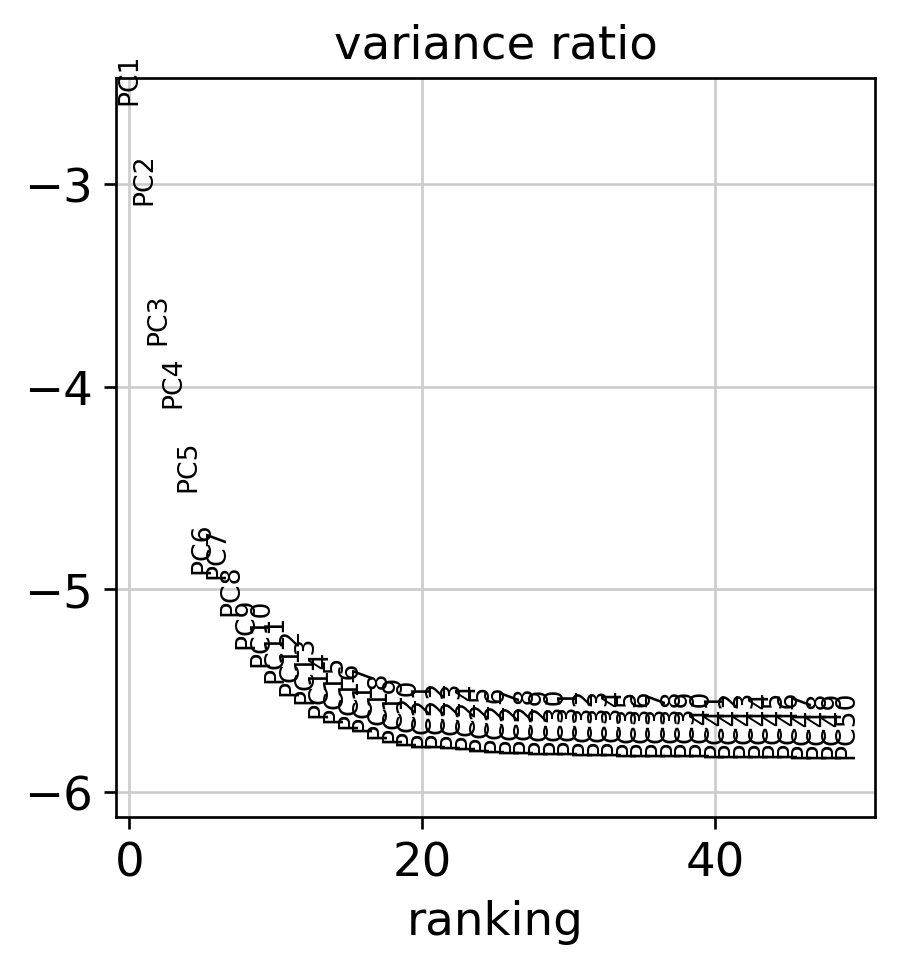

In [3]:
# PCA解释方差图
sc.pl.pca_variance_ratio(adata2, log=True, n_pcs=50, show=False)

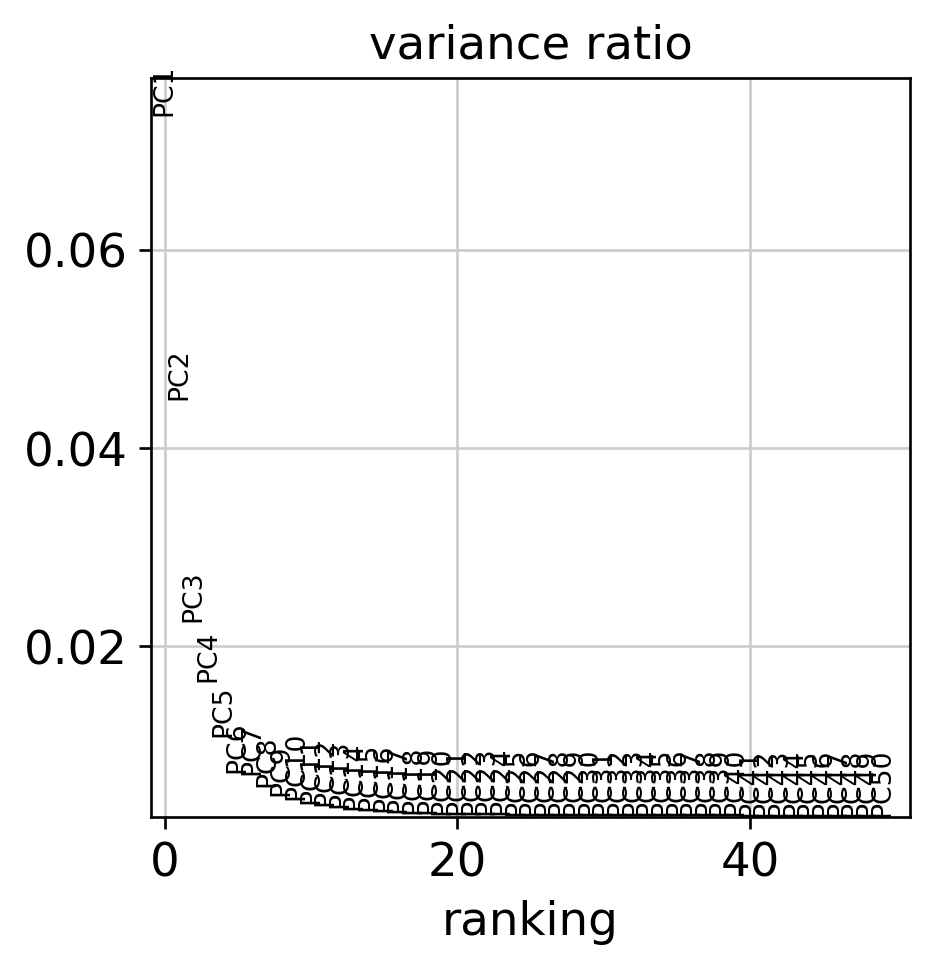

In [4]:
sc.pl.pca_variance_ratio(adata2, log=False, n_pcs=50, show=False)

In [7]:
# 先给一个起始值；最后你可以根据方差图再调
n_pcs_use = 30

# =========================
# 7. Harmony整合
#    关键：batch = library_id / slice，不是 condition
# =========================
X = adata2.obsm["X_pca"].astype("float64")
ho = hm.run_harmony(X, adata2.obs, "batch")

print("X_pca shape:", X.shape)
print("Harmony Z_corr shape:", ho.Z_corr.shape)

adata2.obsm["X_pca_harmony"] = ho.Z_corr
adata2.obsm["X_pca_harmony_use"] = adata2.obsm["X_pca_harmony"][:, :n_pcs_use]

# 保存 PCA + Harmony 后对象
adata2.write(f"{output_path}/adata_after_pca_harmony.h5ad")

# =========================
# 8. 用整合后的 embedding 建 neighbors
# =========================
sc.pp.neighbors(
    adata2,
    n_neighbors=15,
    use_rep="X_pca_harmony_use",
    metric="euclidean",
    random_state=0
)

adata2.write(f"{output_path}/adata_after_harmony_neighbors.h5ad")

2026-04-10 07:53:47,233 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-04-10 07:53:47,234 - harmonypy - INFO -   Parameters:
2026-04-10 07:53:47,235 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-10 07:53:47,235 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-10 07:53:47,236 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-10 07:53:47,236 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-10 07:53:47,237 - harmonypy - INFO -     nclust: 100
2026-04-10 07:53:47,237 - harmonypy - INFO -     block_size: 0.05
2026-04-10 07:53:47,238 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
2026-04-10 07:53:47,239 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2.]
2026-04-10 07:53:47,239 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-10 07:53:47,239 - harmonypy - INFO -     verbose: True
2026-04-10

X_pca shape: (1103409, 50)
Harmony Z_corr shape: (1103409, 50)
computing neighbors
    finished (0:05:39)


In [2]:
output_path = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden"
adata2=sc.read_h5ad(f"{output_path}/adata_after_harmony_neighbors.h5ad")

In [ ]:
# =========================
# 9. 先扫一遍 Leiden resolution
# =========================
for res in [1.5,1.7,1.9,2.1]:
    key = f"leiden_{res}"
    sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)
    print(key, "n_clusters =", adata2.obs[key].nunique())

/tmp/ipykernel_2909558/2667279316.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata2, resolution=res, key_added=key, random_state=0)


leiden_1.5 n_clusters = 14


In [3]:
# 你可以改成你最终想用的值
res = 1.9
sc.tl.leiden(adata2, resolution=res, key_added="cluster", random_state=0)
adata2.obs["cluster"] = adata2.obs["cluster"].astype("category")


/tmp/ipykernel_3037850/4231501533.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata2, resolution=res, key_added="cluster", random_state=0)


In [4]:
# =========================
# 10. UMAP
# =========================
sc.tl.umap(adata2, random_state=0)

adata2.write(f"{output_path}/adata_harmony_leiden_umap_res{res}.h5ad")

# =========================
# 11. 基础UMAP图
# =========================
sc.pl.umap(
    adata2,
    color=["cluster", "condition", "replicate", "library_id"],
    wspace=0.35,
    legend_loc="right margin",
    size=8,
    show=False
)
plt.savefig(os.path.join(output_path, f"umap_cluster_condition_batch_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =========================
# 12. 按切片/文库统一颜色画 UMAP 子图
# =========================
cats = adata2.obs["cluster"].cat.categories.tolist()
cmap = plt.get_cmap("tab20", len(cats))
palette = {c: mpl.colors.to_hex(cmap(i)) for i, c in enumerate(cats)}

handles = [
    Line2D([0], [0], marker='o', color='w', label=c,
           markerfacecolor=palette[c], markersize=6)
    for c in cats
]

library_ids = sorted(adata2.obs["library_id"].astype(str).unique().tolist())

ncols = 5
nrows = int(np.ceil(len(library_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

umap = adata2.obsm["X_umap"]

for ax, lib in zip(axes, library_ids):
    idx = (adata2.obs["library_id"].values.astype(str) == lib)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=3, linewidths=0)
    ax.set_title(lib)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(output_path, f"umap_by_library_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =========================
# 13. 按切片画空间分布图（x, y）
# =========================
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, lib in zip(axes, library_ids):
    idx = (adata2.obs["library_id"].values.astype(str) == lib)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values
    ax.scatter(
        adata2.obs.loc[idx, "x"].astype(float),
        adata2.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    ax.invert_yaxis()
    ax.set_title(lib)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes[len(library_ids):]:
    ax.axis("off")

fig.legend(handles=handles, labels=cats, loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.94, 1])
plt.savefig(os.path.join(output_path, f"spatial_by_library_res{res}.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# 也单独保存每个切片的空间图
for lib in library_ids:
    idx = (adata2.obs["library_id"].values.astype(str) == lib)
    colors = adata2.obs.loc[idx, "cluster"].map(palette).values

    plt.figure(figsize=(5, 5))
    plt.scatter(
        adata2.obs.loc[idx, "x"].astype(float),
        adata2.obs.loc[idx, "y"].astype(float),
        c=colors,
        s=3,
        linewidths=0
    )
    plt.gca().invert_yaxis()
    plt.title(lib)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.savefig(f"{output_path}/spatial_by_slice/{lib}_spatial_clusters.png",
                dpi=300, bbox_inches="tight")
    plt.close()

# =========================
# 14. 保存最终meta
# =========================
adata2.obs.to_csv(f"{output_path}/final_obs_metadata_res{res}.csv")
print("Done.")

Done.


In [9]:
adata2.obs=pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden/final_obs_metadata_res1.9.csv")

In [10]:
adata2.obs

,Unnamed: 0,condition,replicate,slice_id,sample,library_id,batch,raw_cell_id,coord_row_index_plus1,source_intensity_csv,source_coord_csv,coord_index_plus1,x,y,tic,n_met_detected,concat_library_id,cluster
0,ctrl1_slice0_Spot 1,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 1,2,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,2,61072.238281,10187.917969,71.940926,209,ctrl1_slice0,6
1,ctrl1_slice0_Spot 2,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 2,3,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,3,61092.238281,10187.917969,96.516036,225,ctrl1_slice0,6
2,ctrl1_slice0_Spot 3,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 3,4,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,4,61112.238281,10187.917969,130.074396,255,ctrl1_slice0,6
3,ctrl1_slice0_Spot 4,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 4,5,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,5,60572.238281,10167.917969,76.021944,203,ctrl1_slice0,6
4,ctrl1_slice0_Spot 5,ctrl,Rep1,S0,0,ctrl1_slice0,ctrl1_slice0,Spot 5,6,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,6,60592.238281,10167.917969,82.957327,210,ctrl1_slice0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103404,dn3_slice60_Spot 306207,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306207,306207,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306207,2359.611816,5964.661621,1123.678447,258,dn3_slice60,6
1103405,dn3_slice60_Spot 306208,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306208,306208,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306208,2379.611816,5964.661621,1013.270245,262,dn3_slice60,6
1103406,dn3_slice60_Spot 306209,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306209,306209,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306209,2399.611816,5964.661621,676.017845,254,dn3_slice60,6
1103407,dn3_slice60_Spot 306210,dn,Rep3,S60,60,dn3_slice60,dn3_slice60,Spot 306210,306210,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsIn...,/p2/zulab/jtian/data/SA/05_CAST/input/LipidsSp...,306210,2419.611816,5964.661621,657.601784,249,dn3_slice60,6


In [11]:
output_path = "/p2/zulab/jtian/data/SA/06_calculateConcentration/output_PCA_Harmony_Leiden"

In [12]:
root = Path("/p2/zulab/jtian/data/SA/06_calculateConcentration/MetaboliteIntensity")
ctrl_samples = ["ctrl1", "ctrl2", "ctrl3"]
dn_samples   = ["dn1", "dn2", "dn3"]
time_points  = ["0", "15", "30", "45", "60"]

ctrl_list = []
for sample in ctrl_samples:
    for tp in time_points:
        file_path = root / sample / f"{tp}.csv"
        df = pd.read_csv(file_path, sep=";", index_col=0,header=0)
        df_t = df.T.copy()
        df_t.index = [f"{sample}_{tp}_pixel{i+1}" for i in range(df_t.shape[0])]
        ctrl_list.append(df_t)
ctrl_merged = pd.concat(ctrl_list, axis=0)
print("ctrl_merged shape:", ctrl_merged.shape)
print(ctrl_merged.head())
ctrl_merged.to_csv(f'{output_path}/ctrlIntensity_merged.csv', sep=";")


dn_list = []
for sample in dn_samples:
    for tp in time_points:
        file_path = root / sample / f"{tp}.csv"
        df = pd.read_csv(file_path, sep=";", index_col=0,header=0)
        df_t = df.T.copy()
        df_t.index = [f"{sample}_{tp}_pixel{i+1}" for i in range(df_t.shape[0])]
        dn_list.append(df_t)
dn_merged = pd.concat(dn_list, axis=0)
print("dn_merged shape:", dn_merged.shape)
print(dn_merged.head())
dn_merged.to_csv(f'{output_path}/dnIntensity_merged.csv', sep=";")

ctrl_merged shape: (497836, 1245)
m/z             57.0346   58.0302   59.0139   67.0191   68.0143   68.9977   \
ctrl1_0_pixel1  0.000000  0.000000  0.261729  0.000000  0.234178  0.551008   
ctrl1_0_pixel2  0.000000  0.000000  0.140146  0.414068  0.203849  0.000000   
ctrl1_0_pixel3  0.000000  0.258983  0.000000  0.000000  0.267077  0.000000   
ctrl1_0_pixel4  0.201059  0.000000  0.000000  0.495467  0.359034  0.258505   
ctrl1_0_pixel5  0.577206  0.000000  0.849775  0.000000  0.416871  0.000000   

m/z             69.0346   70.0061   70.0299   71.0140   ...  858.5247  \
ctrl1_0_pixel1  1.418844       0.0  0.000000  1.838988  ...  0.000000   
ctrl1_0_pixel2  0.847247       0.0  0.872728  1.739085  ...  0.197479   
ctrl1_0_pixel3  0.000000       0.0  0.922628  2.363223  ...  0.000000   
ctrl1_0_pixel4  0.517010       0.0  0.883225  1.924424  ...  0.157975   
ctrl1_0_pixel5  0.665390       0.0  0.665390  0.801675  ...  0.240502   

m/z             859.5340  860.5360  861.5477  862.5520  86

In [20]:
ctrl_cluster = adata2.obs.loc[
    adata2.obs["library_id"].astype(str).str.startswith("ctrl"),
    "cluster"
].reset_index(drop=True)

dn_cluster = adata2.obs.loc[
    adata2.obs["library_id"].astype(str).str.startswith("dn"),
    "cluster"
].reset_index(drop=True)

if len(ctrl_cluster) != len(ctrl_merged):
    raise ValueError(
        f"ctrl 的 cluster 数量 ({len(ctrl_cluster)}) "
        f"与 ctrl_merged 行数 ({len(ctrl_merged)}) 不一致"
    )

if len(dn_cluster) != len(dn_merged):
    raise ValueError(
        f"dn 的 cluster 数量 ({len(dn_cluster)}) "
        f"与 dn_merged 行数 ({len(dn_merged)}) 不一致"
    )

ctrl_merged.insert(0, "cluster", ctrl_cluster.to_numpy())
dn_merged.insert(0, "cluster", dn_cluster.to_numpy())
print(ctrl_merged.iloc[:5,:5])
print(dn_merged.iloc[:5,:5])

m/z             cluster   57.0346   58.0302   59.0139   67.0191
ctrl1_0_pixel1        6  0.000000  0.000000  0.261729  0.000000
ctrl1_0_pixel2        6  0.000000  0.000000  0.140146  0.414068
ctrl1_0_pixel3        6  0.000000  0.258983  0.000000  0.000000
ctrl1_0_pixel4        6  0.201059  0.000000  0.000000  0.495467
ctrl1_0_pixel5        6  0.577206  0.000000  0.849775  0.000000
m/z           cluster   57.0346   58.0302   59.0139   67.0191
dn1_0_pixel1        6  0.000000  0.712215  0.000000  0.000000
dn1_0_pixel2        6  0.000000  1.836354  3.292773  1.308666
dn1_0_pixel3        6  0.000000  1.547361  0.000000  1.246902
dn1_0_pixel4        6  0.830629  0.540409  0.000000  0.000000
dn1_0_pixel5        6  0.000000  0.000000  0.000000  0.202554


In [21]:
ctrl_mz_cols = [c for c in ctrl_merged.columns if c != "cluster"]
ctrl_mz_cols = sorted(ctrl_mz_cols, key=lambda x: float(x))
ctrl_merged = ctrl_merged[["cluster"] + ctrl_mz_cols]

ctrl_tmp = ctrl_merged.copy()
ctrl_tmp["group"] = ctrl_tmp.index.to_series().str.replace(r"_pixel\d+$", "", regex=True)
ctrl_cluster_mean = ctrl_tmp.groupby(
    ["group", "cluster"],
    sort=False
)[ctrl_mz_cols].mean()
ctrl_cluster_mean.index = [
    f"{group}_cluster{cluster}"
    for group, cluster in ctrl_cluster_mean.index
]
print(ctrl_cluster_mean.head())


m/z               57.0346   58.0302   59.0139   67.0191   68.0143   68.9977   \
ctrl1_0_cluster6  0.442079  0.779413  2.641048  0.776247  1.955066  2.777006   
ctrl1_0_cluster0  0.589413  0.977542  3.862409  1.043806  2.097208  3.524998   
ctrl1_0_cluster9  0.606147  1.111074  3.856899  1.071349  2.145932  3.560619   
ctrl1_0_cluster2  0.665563  1.235883  3.899104  1.100908  2.441942  3.736250   
ctrl1_0_cluster1  0.618540  1.158384  3.966068  1.077232  2.193449  3.559935   

m/z               69.0346   70.0061   70.0299    71.0140   ...  858.5247  \
ctrl1_0_cluster6  4.250706  1.369837  4.986802  11.815677  ...  1.765752   
ctrl1_0_cluster0  6.988048  1.852798  6.004920  17.266713  ...  5.938057   
ctrl1_0_cluster9  6.580591  1.895486  6.826066  18.143065  ...  6.050663   
ctrl1_0_cluster2  6.375033  2.034196  7.326082  17.769640  ...  4.126668   
ctrl1_0_cluster1  6.646214  1.854263  6.830821  17.667463  ...  6.218108   

m/z               859.5340  860.5360  861.5477  862.5520  863.

In [ ]:
ctrl_sort_df = ctrl_cluster_mean.copy()
ctrl_parts = ctrl_sort_df.index.to_series().str.extract(
    r"^ctrl(\d+)_(\d+)_cluster(\d+)$"
)
ctrl_sort_df["_sample_num"] = ctrl_parts[0].astype(int)
ctrl_sort_df["_time"] = ctrl_parts[1].astype(int)
ctrl_sort_df["_cluster"] = ctrl_parts[2].astype(int)
ctrl_sort_df = ctrl_sort_df.sort_values(
    by=["_sample_num", "_cluster", "_time"],
    kind="stable"
)
ctrl_cluster_mean = ctrl_sort_df.drop(
    columns=["_sample_num", "_time", "_cluster"]
)


ctrl1_0_cluster0     3.524998
ctrl1_15_cluster0    3.688526
ctrl1_30_cluster0    3.461286
ctrl1_45_cluster0    3.603368
ctrl1_60_cluster0    3.610726
ctrl1_0_cluster1     3.559935
ctrl1_15_cluster1    3.747301
ctrl1_30_cluster1    3.575594
ctrl1_45_cluster1    3.712068
ctrl1_60_cluster1    3.723174
Name: 68.9977, dtype: float64


In [23]:
print(ctrl_cluster_mean.iloc[:10,:5])

m/z                 57.0346   58.0302   59.0139   67.0191   68.0143
ctrl1_0_cluster0   0.589413  0.977542  3.862409  1.043806  2.097208
ctrl1_15_cluster0  0.712351  1.097903  4.592610  1.151200  1.893821
ctrl1_30_cluster0  0.723099  1.012273  4.902387  1.220349  1.607830
ctrl1_45_cluster0  0.745054  1.042486  5.367784  1.303092  1.615560
ctrl1_60_cluster0  0.800204  1.054100  5.603150  1.398527  1.587317
ctrl1_0_cluster1   0.618540  1.158384  3.966068  1.077232  2.193449
ctrl1_15_cluster1  0.732510  1.257879  4.762776  1.208755  2.037095
ctrl1_30_cluster1  0.740250  1.152353  5.139495  1.249924  1.786684
ctrl1_45_cluster1  0.808818  1.159096  5.525949  1.327425  1.767155
ctrl1_60_cluster1  0.802289  1.206121  5.807276  1.439215  1.763622


In [24]:
dn_mz_cols = [c for c in dn_merged.columns if c != "cluster"]
dn_mz_cols = sorted(dn_mz_cols, key=lambda x: float(x))
dn_merged = dn_merged[["cluster"] + dn_mz_cols]

dn_tmp = dn_merged.copy()
dn_tmp["group"] = dn_tmp.index.to_series().str.replace(r"_pixel\d+$", "", regex=True)
dn_cluster_mean = dn_tmp.groupby(
    ["group", "cluster"],
    sort=False
)[dn_mz_cols].mean()
dn_cluster_mean.index = [
    f"{group}_cluster{cluster}"
    for group, cluster in dn_cluster_mean.index
]

print(dn_cluster_mean.head())

m/z              57.0346   58.0302   59.0139   67.0191   68.0143   68.9977   \
dn1_0_cluster6   0.533098  1.037683  3.379292  0.899188  1.881573  3.331844   
dn1_0_cluster1   0.671982  1.106306  4.648302  1.112465  2.250409  4.228250   
dn1_0_cluster4   0.687262  1.040612  4.722729  1.117475  2.199797  4.286429   
dn1_0_cluster15  0.657477  0.954193  4.751789  1.086712  2.240768  4.297643   
dn1_0_cluster9   0.711374  1.092952  4.778059  1.094799  2.197285  4.302387   

m/z              69.0346   70.0061   70.0299    71.0140   ...  862.5520  \
dn1_0_cluster6   4.274288  1.642736  6.332894  15.354779  ...  1.241766   
dn1_0_cluster1   6.945143  2.310391  6.686326  21.340294  ...  4.148329   
dn1_0_cluster4   6.983096  2.229710  6.386793  21.406694  ...  3.626692   
dn1_0_cluster15  7.027592  2.284396  6.581921  21.327829  ...  3.584346   
dn1_0_cluster9   6.903728  2.295374  6.681292  21.772788  ...  4.127472   

m/z              863.5618  864.5684  884.5423  888.5673  918.5629  919.555

In [25]:
dn_sort_df = dn_cluster_mean.copy()

dn_parts = dn_sort_df.index.to_series().str.extract(
    r"^dn(\d+)_(\d+)_cluster(\d+)$"
)

dn_sort_df["_sample_num"] = dn_parts[0].astype(int)
dn_sort_df["_time"] = dn_parts[1].astype(int)
dn_sort_df["_cluster"] = dn_parts[2].astype(int)

dn_sort_df = dn_sort_df.sort_values(
    by=["_sample_num", "_cluster", "_time"],
    kind="stable"
)

dn_cluster_mean = dn_sort_df.drop(
    columns=["_sample_num", "_time", "_cluster"]
)
print(dn_cluster_mean.iloc[:10,:5])

m/z               57.0346   58.0302   59.0139   67.0191   68.0143
dn1_0_cluster0   0.691332  0.971103  4.595239  1.120743  2.130734
dn1_15_cluster0  0.717620  1.111676  4.782537  1.257936  1.828317
dn1_30_cluster0  0.817012  1.231013  5.349771  1.389802  1.797172
dn1_45_cluster0  0.835403  1.215215  5.579197  1.496575  1.692097
dn1_60_cluster0  0.776532  1.073334  5.477505  1.518366  1.537741
dn1_0_cluster1   0.671982  1.106306  4.648302  1.112465  2.250409
dn1_15_cluster1  0.753743  1.227946  4.898757  1.253686  1.861246
dn1_30_cluster1  0.803205  1.293474  5.365327  1.348591  1.974609
dn1_45_cluster1  0.856236  1.334672  5.720376  1.518480  1.857009
dn1_60_cluster1  0.842565  1.230295  5.707957  1.557331  1.690804


In [26]:
ctrl_cluster_mean.to_csv(f'{output_path}/ctrlIntensityMeanByCluster.csv')
dn_cluster_mean.to_csv(f'{output_path}/dnIntensityMeanByCluster.csv')

In [27]:
def linreg_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan

    xm = x.mean()
    ym = y.mean()
    dx = x - xm
    dy = y - ym

    varx = np.sum(dx * dx)
    if varx == 0:
        return np.nan, np.nan, np.nan, np.nan

    slope = np.sum(dx * dy) / varx
    intercept = ym - slope * xm

    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - ym) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # y=0 时 x 截距：x0 = -b/a；取绝对值
    x0_abs = np.abs(-intercept / slope) if slope != 0 else np.nan
    return slope, intercept, r2, x0_abs

In [28]:
def build_linreg_result(df):
    """
    df 的行名格式：
    ctrl1_0_cluster0 / dn1_15_cluster2 这类
    列名为 m/z
    """
    tmp = df.copy()

    # 解析行名：样本号、时间、cluster
    parts = tmp.index.to_series().str.extract(
        r"^([A-Za-z]+\d+)_(\d+)_cluster(\d+)$"
    )

    tmp["_sample"] = parts[0]
    tmp["_time"] = parts[1].astype(int)
    tmp["_cluster"] = parts[2].astype(int)

    # m/z 列
    mz_cols = [c for c in tmp.columns if c not in ["_sample", "_time", "_cluster"]]
    mz_cols = sorted(mz_cols, key=lambda x: float(x))

    result_rows = []

    # 按 sample + cluster 分组
    for (sample, cluster), sub in tmp.groupby(["_sample", "_cluster"], sort=False):
        sub = sub.sort_values("_time")

        # 这里 x 实际上就是 [0,15,30,45,60]
        x = sub["_time"].to_numpy(dtype=float)

        for mz in mz_cols:
            y = sub[mz].to_numpy(dtype=float)
            slope, intercept, r2, x0_abs = linreg_stats(x, y)

            result_rows.append({
                "sample": sample,
                "mz": float(mz),
                "cluster": int(cluster),
                "slope": slope,
                "intercept": intercept,
                "r2": r2,
                "x0_abs": x0_abs
            })

    result_df = pd.DataFrame(result_rows)

    # 排序：先 sample，再 cluster，再 mz
    parts2 = result_df["sample"].str.extract(r"^([A-Za-z]+)(\d+)$")
    result_df["_prefix"] = parts2[0]
    result_df["_sample_num"] = parts2[1].astype(int)

    result_df = result_df.sort_values(
        by=["_prefix", "_sample_num", "cluster", "mz"],
        kind="stable"
    ).drop(columns=["_prefix", "_sample_num"])

    result_df = result_df.reset_index(drop=True)
    return result_df

In [29]:
ctrl_linreg_result = build_linreg_result(ctrl_cluster_mean)
dn_linreg_result = build_linreg_result(dn_cluster_mean)

print(ctrl_linreg_result.head())
print(dn_linreg_result.head())

  sample       mz  cluster     slope  intercept        r2       x0_abs
0  ctrl1  57.0346        0  0.003029   0.623168  0.859789   205.764307
1  ctrl1  58.0302        0  0.000651   1.017321  0.116717  1561.898359
2  ctrl1  59.0139        0  0.028378   4.014337  0.964585   141.460926
3  ctrl1  67.0191        0  0.005742   1.051128  0.995881   183.052588
4  ctrl1  68.0143        0 -0.008654   2.019956  0.820091   233.423114
  sample       mz  cluster     slope  intercept        r2      x0_abs
0    dn1  57.0346        0  0.001921   0.709943  0.538117  369.526838
1    dn1  58.0302        0  0.002053   1.058868  0.207101  515.680125
2    dn1  59.0139        0  0.017075   4.644612  0.847581  272.018690
3    dn1  67.0191        0  0.006893   1.149908  0.952463  166.833117
4    dn1  68.0143        0 -0.008815   2.061654  0.917326  233.887906


In [30]:
ctrl_r2_mean = (
    ctrl_linreg_result
    .groupby(["sample", "mz"], as_index=False)["r2"]
    .mean()
    .rename(columns={"r2": "mean_r2"})
)

ctrl_good = ctrl_r2_mean[ctrl_r2_mean["mean_r2"] >= 0.9].copy()

# 每个样本筛出来多少个代谢物
ctrl_count = (
    ctrl_good
    .groupby("sample", as_index=False)
    .size()
    .rename(columns={"size": "n_metabolites_r2_ge_0.9"})
)

print("ctrl_good:")
print(ctrl_good.head())

print("ctrl_count:")
print(ctrl_count)


dn_r2_mean = (
    dn_linreg_result
    .groupby(["sample", "mz"], as_index=False)["r2"]
    .mean()
    .rename(columns={"r2": "mean_r2"})
)

dn_good = dn_r2_mean[dn_r2_mean["mean_r2"] >= 0.9].copy()

dn_count = (
    dn_good
    .groupby("sample", as_index=False)
    .size()
    .rename(columns={"size": "n_metabolites_r2_ge_0.9"})
)

print("dn_good:")
print(dn_good.head())

print("dn_count:")
print(dn_count)

ctrl_good:
   sample       mz   mean_r2
2   ctrl1  59.0139  0.943166
14  ctrl1  73.0294  0.944006
15  ctrl1  74.0246  0.942820
35  ctrl1  88.0405  0.960542
37  ctrl1  89.0246  0.976530
ctrl_count:
  sample  n_metabolites_r2_ge_0.9
0  ctrl1                      149
1  ctrl2                       62
2  ctrl3                      249
dn_good:
   sample       mz   mean_r2
34    dn1  88.0405  0.939982
35    dn1  89.0246  0.949961
37    dn1  90.0282  0.901109
46    dn1  96.9696  0.930521
49    dn1  97.9740  0.902892
dn_count:
  sample  n_metabolites_r2_ge_0.9
0    dn1                       90
1    dn2                      108
2    dn3                       95
